<a href="https://colab.research.google.com/github/Basurero2/Regresion-lineal---Tecnicas-avanzadas-de-Modelado/blob/juan-carlos/precios_de_inmuebles_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Precificación inmobiliaria**

**Objetivo**: Estimar los precios de los inmuebles.
 * Identificar los aspectos que tienen más influencia en la precificación de los inmuebles.
 * Entender cuál de todos estos aspectos es el más relevante.
 * Precificar un inmueble nuevo.

Base de datos simplificada e inspirada en [House Prices](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)



![](https://i.imgur.com/A8X79yq.jpeg)


# 1. Ajustando una recta

## Conociendo los datos

**Diccionario**:
- area_primer_piso: Se refiere al área del primer piso de la propiedad, medida en metros cuadrados.
- existe_segundo_piso: Esta variable es binaria, indicando si la propiedad tiene o no un segundo piso. Puede ser representada como 1 para "sí" y 0 para "no".
- area_segundo_piso: Si la propiedad tiene un segundo piso, esta variable representa el área total del segundo piso, medida en metros cuadrados.
- cantidad_baños: Indica el número total de baños en la propiedad.
- capacidad_coches_garaje: Esta variable indica la capacidad del garaje de la propiedad, es decir, el número máximo de coches que pueden estacionarse en el garaje.
- calidad_de_la_cocina_Excelente: Esta es una variable categórica que evalúa la calidad de la cocina en la propiedad. En este caso, se asume que si la cocina es considerada "Excelente" se representa por 1, y de lo contrario, por 0.
- precio_de_venta: Este es el precio de venta de la propiedad en reales. Es la variable objetivo que se intenta predecir utilizando los otros atributos de la propiedad.

In [ ]:
import pandas as pd


In [ ]:
#Leyendo los datos
datos = pd.read_csv("/content/precios_casas.csv")
datos.head()


,Id,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente,precio_de_venta
0,1,79.5224,1,79.3366,2,548,0,1027905.0
1,2,117.2398,0,0.0000,2,460,0,894795.0
2,3,85.4680,1,80.4514,2,608,0,1101855.0
3,4,89.2769,1,70.2324,1,642,0,690200.0
4,5,106.3705,1,97.8237,2,836,0,1232500.0


In [ ]:
#Cuáles factores fueron colectados
datos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Id                           1438 non-null   int64  
 1   area_primer_piso             1438 non-null   float64
 2   tiene_segundo_piso           1438 non-null   int64  
 3   area_segundo_piso            1438 non-null   float64
 4   cantidad_banos               1438 non-null   int64  
 5   capacidad_carros_garage      1438 non-null   int64  
 6   calidad_de_cocina_excelente  1438 non-null   int64  
 7   precio_de_venta              1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [ ]:
datos = datos.drop(columns=["Id"])  #elminamos columna Id yaque es lo mismo que el indice

In [ ]:
datos.head()

,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente,precio_de_venta
0,79.5224,1,79.3366,2,548,0,1027905.0
1,117.2398,0,0.0000,2,460,0,894795.0
2,85.4680,1,80.4514,2,608,0,1101855.0
3,89.2769,1,70.2324,1,642,0,690200.0
4,106.3705,1,97.8237,2,836,0,1232500.0


## Correlación

**¿Cuáles factores están relacionados con el precio de la casa? ¿Cómo es esa relación?**

El coeficiente de correlación de Pearson nos permite medir la relación lineal entre variables, ofreciendo una escala que varía de -1 a 1, la cual interpretamos según su intensidad y dirección:

* **-1**: correlación negativa perfecta: a medida que una variable aumenta, la otra disminuye.  
* **0**: no hay relación lineal entre las variables.  
* **1**: correlación positiva perfecta: a medida que una variable aumenta, la otra también aumenta.  



In [ ]:
# Correlación
corr = datos.corr()
corr
#DataFrame de dimensiones n x n (n : variables), muestra correlaciones
# -1 a 0, correlacion inversa
# 0 a 1, correlacion directa
# mientras mas cerca este a los extremos el tipo de correlacion es mas fuerte


,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente,precio_de_venta
area_primer_piso,1.000000,-0.376805,-0.253793,0.369368,0.481231,0.323496,0.616557
tiene_segundo_piso,-0.376805,1.000000,0.917101,0.292780,-0.001284,-0.020045,0.138541
area_segundo_piso,-0.253793,0.917101,1.000000,0.412777,0.131938,0.025248,0.305311
cantidad_banos,0.369368,0.292780,0.412777,1.000000,0.409281,0.154102,0.563132
capacidad_carros_garage,0.481231,-0.001284,0.131938,0.409281,1.000000,0.276759,0.640214
calidad_de_cocina_excelente,0.323496,-0.020045,0.025248,0.154102,0.276759,1.000000,0.496223
precio_de_venta,0.616557,0.138541,0.305311,0.563132,0.640214,0.496223,1.000000


In [ ]:
corr["precio_de_venta"]  #obtenemos las correlaciones de la variable "precio_de_venta", Serie

,precio_de_venta
area_primer_piso,0.616557
tiene_segundo_piso,0.138541
area_segundo_piso,0.305311
cantidad_banos,0.563132
capacidad_carros_garage,0.640214
calidad_de_cocina_excelente,0.496223
precio_de_venta,1.000000


In [ ]:
corr["area_primer_piso"]

,area_primer_piso
area_primer_piso,1.000000
tiene_segundo_piso,-0.376805
area_segundo_piso,-0.253793
cantidad_banos,0.369368
capacidad_carros_garage,0.481231
calidad_de_cocina_excelente,0.323496
precio_de_venta,0.616557


In [ ]:
# Actividad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Grafico de calor triangular
- es triangular por la relacion A x B es lo mismo que B x A, entonces hay una simetria, por eso solo se muestra una mitad
- Para ver todas las relaciones, busca tanto en grafica el eje y, eje x,
las variables se repiten

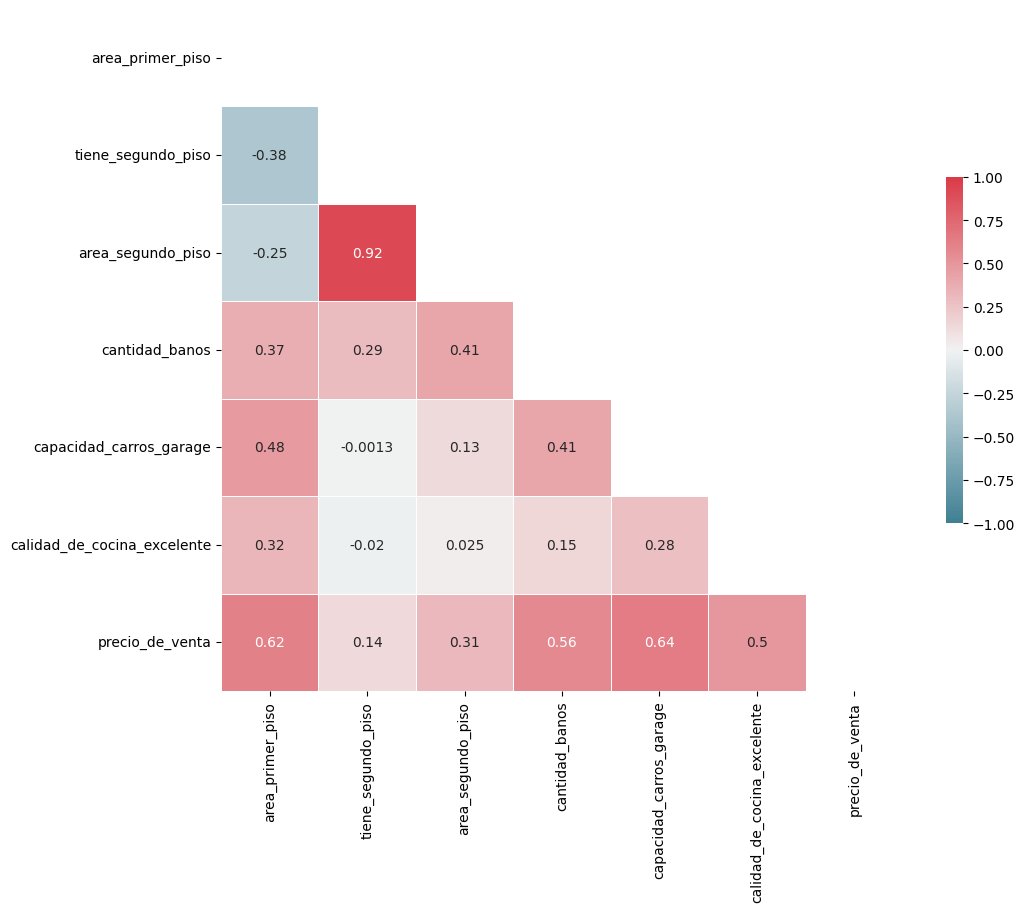

In [ ]:


# ¿Qué factores están más correlacionados?

# Generar una máscara para el triángulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar la figura de matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Generar el mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Mostrar el mapa de calor (heatmap)
plt.show()

## Relacionando variables

In [ ]:
# importando los paquetes para la visualización}
import matplotlib.pyplot as plt
import plotly.express as px


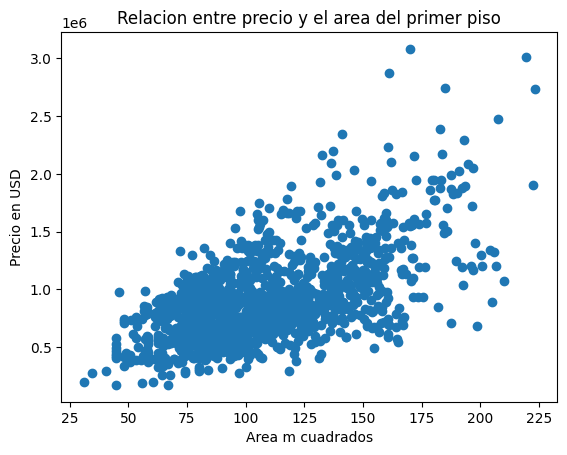

In [ ]:
# Cómo se relacionan el área construída y el precio del inmueble?
plt.scatter(datos["area_primer_piso"], datos["precio_de_venta"])
plt.title("Relacion entre precio y el area del primer piso")
plt.xlabel("Area m cuadrados")
plt.ylabel("Precio en USD")
plt.show()



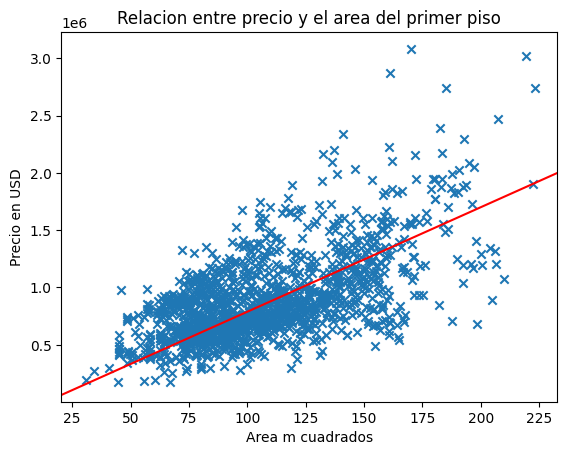

In [ ]:
# Aparentemente mientras mayor es el área del primer piso, mayor es el precio de la casa.
# E si quisieramos trazar una línea que nos permita describir este comportamiento?
plt.scatter(datos["area_primer_piso"], datos["precio_de_venta"], marker="x")
plt.title("Relacion entre precio y el area del primer piso")
plt.xlabel("Area m cuadrados")
plt.ylabel("Precio en USD")

plt.axline(xy1=(30, 150000), xy2=(200, 1700000), color="r")

plt.show()


## Mejor recta

¿Qué es OLS?:

- OLS significa Ordinary Least Squares (en español: Mínimos Cuadrados Ordinarios).

- ¿Qué significa?: Es el método estándar para la Regresión Lineal.

- ¿Qué hace?: Su "misión" es dibujar una línea recta de tal forma que la distancia al cuadrado entre esa línea y todos tus puntos azules sea la mínima posible.

- En resumen: Es la línea que mejor representa la tendencia general. Si la línea sube, la relación es positiva; si baja, es negativa.

Esta recta no es solo un adorno; tiene un poder predictivo:
- Predicción: Si tienes una casa nueva que mide 150 $m^2$, solo tienes que buscar el 150 en el eje X, subir hasta chocar con la línea roja, y ver qué precio marca el eje Y. Esa sería tu estimación basada en los datos.

- Validación: Si la línea está muy cerca de la mayoría de los puntos, tu modelo es muy confiable. Si los puntos están muy dispersos y lejos de la línea roja, la relación es débil.

$$y = mx + b$$
- $y$ (Precio): Lo que queremos predecir.
- $x$ (Área): La variable que conocemos.
- $m$ (Pendiente): Cuánto sube el precio por cada metro cuadrado adicional.
- $b$ (Intercepto): El valor teórico del precio si el área fuera cero.

In [ ]:
# Cuál es la recta que mejor se ajusta a esta relación
px.scatter(datos, x="area_primer_piso", y="precio_de_venta", trendline="ols", trendline_color_override="red")
# trendline = "ols" : linea regresion lineal, indica el comportamiento de nuestros datos
# OLS : Ordinary Least Squares (en español: Mínimos Cuadrados Ordinarios).
# trendline : Es el modelo que "dibuja" la tendencia.


# 2. Explicando la recta
Ajustamos una recta entre los $m^2$ del primer piso y el precio de la casa. Queremos explicar el precio de la casa a partir de su tamaño, por eso decimos que:

* Variable explicativa/independiente: Área del primer piso (x)
* Variable de respuesta/dependiente: Precio de la casa  (y)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

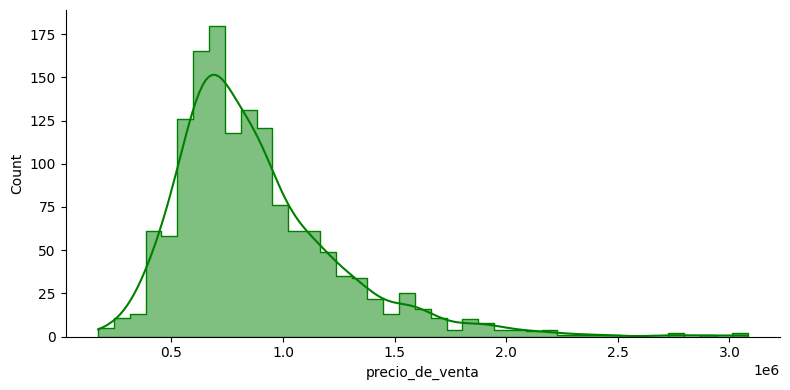

In [ ]:
#Quién es nuestra variable de respuesta?

sns.displot(datos["precio_de_venta"], color="green" , kde=True, element="step", height=4, aspect=2)  #grafico de frecuencias
plt.show()

### Separando datos para entrenamiento y para prueba

El conjunto de **entrenamiento** se utiliza para ajustar el modelo, mientras que el conjunto de **prueba** se usa para evaluar su desempeño al predecir precios de viviendas no vistos durante el entrenamiento, lo que ayuda a la generalización del modelo.

In [ ]:
# import train_test_split
from sklearn.model_selection import train_test_split

In [ ]:
y = datos["precio_de_venta"]                  #variable dependiente, Serie
X = datos.drop(columns=["precio_de_venta"])   #variables independientes, excepto la misma variable y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=230)
# X : variables independiantes, base de datos (Poblacion), de donde seleccionara datos
# y : variable dependiente, variable que queremos predecir (Serie)
# test_size : % tamaño de muestra de X que ira al conjunto de prueba, lo restante ira al conjunto de entrenamiento
# random_state : semilla, para que obtengamos siempre le mismo conjunto de datos en cada conjunto

#X_train : conjunto de entrenamiento (DataFrame) variables independientes (eje x)
#y_train : conjunto de entrenamiento (Serie) varible dependiente (eje y)
#X_test : conjunto de prueba (DataFrame) variables independientes (eje x)
#y_test : conjunto de prueba (Serie) variable dependiente (eje y)
# cada conjunto, los puntos estan relacionados por fila (indice)
#train_test_split() : reparto inteligente de una base de datos en cuatro conjuntos

In [ ]:
X_train.head()  #eje x de conjunto de entrenamiento

,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente
1303,65.7732,0,0.0000,1,0,0
326,55.3684,1,55.3684,1,189,0
386,74.6916,1,107.4853,2,560,0
615,103.6764,0,0.0000,1,440,0
236,94.2006,1,67.8170,2,457,0


In [ ]:
y_train.head()  #eje y del conjunto de entrenamiento

,precio_de_venta
1303,406725.0
326,384540.0
386,1059950.0
615,788800.0
236,958885.0


In [ ]:
#Datos de entrenamiento para usar la fórmula
df_train = pd.DataFrame(X_train)        #creamos un DataFrame con conjunto de entramiento (eje x) las variables independientes
df_train["precio_de_venta"] = y_train   #creamos una columna para guardar el conjunto de entrenamiento (eje y) la variable dependiente


In [ ]:
# import ols
from statsmodels.formula.api import ols


In [ ]:
# ajustando el primer modelo
model_0 = ols("precio_de_venta ~ area_primer_piso", data=df_train).fit()
# data : base de datos de donde buscara (conjunto de entrenamiento)
# "precio_de_venta ~ area_primer_piso" : prediccion a la variable "precio_de_venta" (dependiente)(y) respecto a variable "area_primer_piso" (independiente)(x)
# fit() : calcula los parametros, usa los datos listo del modelo OLS y halla m, b, pvalues, rsquared
# ols() : especifica la estructura y el modelo que se usara (recta de regresion)

In [ ]:
model_0

## Analizando los coeficientes

(intensidad, dirección y significancia)




$$Precio = Intercepto + (6793.64 \times Area)$$

In [ ]:
# visualizando los parámetros

model_0.params
# intercepto o b : punto interseccion en el eje y cuando x = 0, el precio es 152909.288334 (teorico)
# area_primer_psio : es el coeficiente principal de la ecuacion, la pendiente,
#   por cada metro cuadrado adicional (x>0) el precio (x = 0, y = 152909.288334) aumentara en promedio 6793.641641
# Precio = Intercepto + (6793.64 \times Area)


,0
Intercept,152909.288334
area_primer_piso,6793.641641


Explicacion
- std err : la variacion del coeficiente (prendiente) en promedio (error promedio) al usar otros conjunto de datos
- t : coefcieinte / std err   , si t>2 --> variable importante
- P>|t| : probabilidad de que la relacion sea "suerte" : si el p-value es menor a 0.05, decimos que la variable es significativa (que sí influye de verdad en el precio).
- [0.025  0.975] : 95% (0.975 - 0.025) confianza de que coeficiente estre entre intervalos 6253.11 y 7334.17.

In [ ]:
# El resumen del modelo
print(model_0.summary())

                            OLS Regression Results                            
Dep. Variable:        precio_de_venta   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          2.22e-105
Time:                        16:45:27   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1.529e+05   3.07e+04  

- El **punto de intercepción** es el valor esperado del precio de la casa cuando todas las demás variables son cero. En este caso, cuando todas las demás variables, incluida el área del primer piso, son cero, el precio esperado de la casa es de $145.196,40. No siempre se tiene una interpretación práctica para este número.

- El **efecto individual** del área es de \$6.833,97. Esto indica que por cada metro cuadrado adicional al área del primer piso, se espera que el precio de la casa aumente en promedio \$6.833,97.

<img src="https://i.ibb.co/CJwfMgW/coeficientes.png" alt="coeficientes" border="0">


## Explicabilidad del modelo

**¿En qué medida la variación del área explica los diversos precios de las casas?**  

En este caso, recurrimos a la métrica R², el coeficiente de determinación. El R² varía de 0 a 1, donde 1 indica un ajuste perfecto del modelo a los datos, es decir, todas las variaciones en la variable dependiente son explicadas por las variables independientes en el modelo. Por otro lado, un R² de 0 indica que el modelo no explica ninguna variabilidad en la variable dependiente.

$R^2 = \text{Variación de la Recta} / \text{Variación del Promedio}$.

 $R^2 = \frac{\text{Variación Explicada}}{\text{Variación Total}}$.

- El numerador $\sum (\hat{y}_i - \bar{y})^2$ (Variación Explicada): Esta es la clave. Mide qué tan lejos están tus predicciones (la línea roja) del promedio.
- El denominador $\sum (y_i - \bar{y})^2$ (Variación Total): Mide qué tan lejos están los precios reales del promedio. Es el "desorden total" que había al principio.


- $\hat{y}_i$ ($y$ con "sombrero" o virgulilla): Es el valor que predice tu recta de regresión. Es el punto exacto sobre la línea roja para un área determinada. Representa lo que el modelo "cree" que debería costar la casa.
- $y_i$ ($y$ normal): Es el valor real observado. El precio que de verdad se pagó por la casa y que aparece en tu base de datos.
- $\bar{y}$ ($y$ con barra): Es el promedio de todos los precios. Es tu línea base, el modelo más simple posible.

El porcentaje restante de R² o que no explica esta varuable, significa que esas variaciones se deben a otras variables

In [ ]:
# observando el R²   , es un parametro por eso no lleva ()
model_0.rsquared

#esta variable (area_primer_piso) con el modelo OLS solo explica el 37% de las variaciones del precio_de_venta
#el 63% restante es explicado por otras variables

np.float64(0.37728010994297867)

## Entendiendo el resíduo

In [ ]:
# Quiénes son los residuos?
model_0.resid

#Serie, muestra todos los residuos para cada Area (index : indice Area en el DataFrame)
#residios : valor real - valor obtenido en la recta regresion
#  positivos : valor real esta por encima de la recta regresion
#  negativos : valor real esta por debajo de la recta regresion

,0
1303,-193023.838744
326,-144522.356193
386,399612.747641
615,-68449.596607
236,166010.592859
...,...
777,465872.680999
271,-497642.319788
723,461150.204718
560,-540482.733402


In [ ]:
model_0.resid.sum()  #la suma de los residuos es aprox 0, tiende a 0


np.float64(1.8440186977386475e-07)

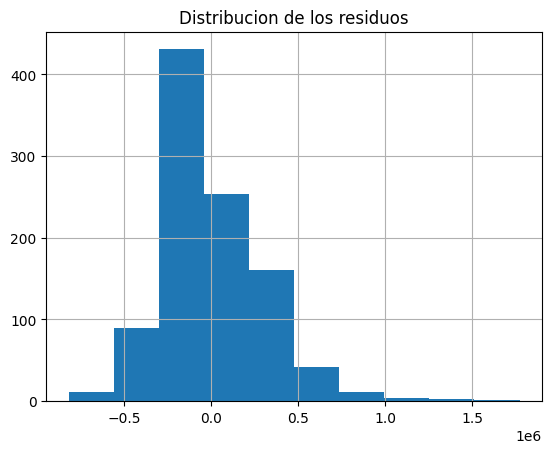

In [ ]:
# Cómo están distribuidos
model_0.resid.hist()
plt.title("Distribucion de los residuos")
plt.show()

#vemos que hay mas frecuencia de residuos entre -500000, 500000
#residuo = 0, valor real coincide con la recta regresion
# ideal es que los residuos ronden alrededor de 0
# si los residuos tienden a 0 mayor es la generalizacion


<img src="https://i.ibb.co/zGTB35V/residuos.png" alt="residuos" border="0">

## Obteniendo el R² de la previsión

In [ ]:
# definiendo la 'Y' prevista
y_predict = model_0.predict(X_test)

#le damos un conjunto de prueba para que nos prediga el precio de venta
# (usara la formula hallada con el conjunto de entrenamiento)

#solo usara la variable con la que el modelo_0 uso, osea solo tomara valores de "area_primer_piso"

In [ ]:
y_predict    #valores predecidos usando conjunto de prueba,  valores resultados de la formula  ax + b (recta)
             # hallada en con el conjunto entrenamiento


,0
997,7.979234e+05
805,6.565505e+05
1138,9.512879e+05
1391,1.316712e+06
516,9.519190e+05
...,...
1051,7.165078e+05
484,7.575312e+05
1357,4.577447e+05
844,7.284992e+05


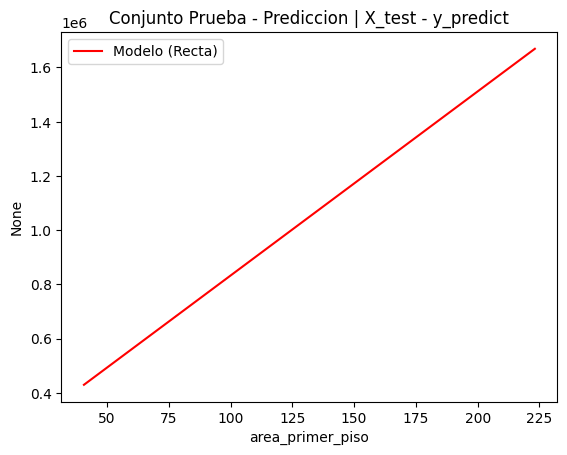

In [ ]:
sns.lineplot(x=X_test['area_primer_piso'], y=y_predict, color="red", label="Modelo (Recta)")
plt.title("Conjunto Prueba - Prediccion | X_test - y_predict")
plt.show()


In [ ]:
y_test    #valores de los precios reales del conjunto prueba


,precio_de_venta
997,419050.0
805,902190.0
1138,886907.0
1391,1267010.0
516,867680.0
...,...
1051,665550.0
484,655690.0
1357,409190.0
844,936453.5


In [ ]:
X_test   #valores del conjunto prueba, variable independiente
         #usara para hallar y_predict, pero solo usara las variables con lo que el modelo se entreno

,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente
997,94.9438,0,0.0000,1,280,0
805,74.1342,1,78.2218,2,595,0
1138,117.5185,0,0.0000,2,502,0
1391,171.3076,0,0.0000,2,620,0
516,117.6114,0,0.0000,2,453,0
...,...,...,...,...,...,...
1051,82.9597,0,0.0000,1,576,0
484,88.9982,1,57.5980,1,240,0
1357,44.8707,1,46.8216,1,264,0
844,84.7248,1,47.7506,1,216,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

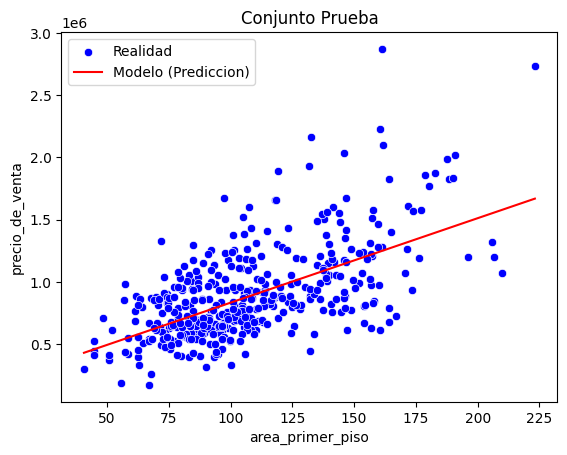

In [ ]:
# Graficar la realidad (puntos) y la predicción (línea)
sns.scatterplot(x=X_test['area_primer_piso'], y=y_test, color="blue", label="Realidad")
sns.lineplot(x=X_test['area_primer_piso'], y=y_predict, color="red", label="Modelo (Prediccion)")
plt.title("Conjunto Prueba")
plt.show()

In [ ]:
# importando el r2_score

from sklearn.metrics import r2_score


 $R^2 = \frac{\text{Variación Explicada}}{\text{Variación Total}}$.

numerador : $\sum ({y_{predict}} - \bar{y})^2$

denominador : $\sum (y_i - \bar{y})^2$

${y_{predict}}$ : precios predecidos : recta

$\bar{y}$ : promedio de precios reales y_test.

$y_i$ : precios reales y_test


In [ ]:
round(r2_score(y_test, y_predict), 2)

#aplica la formuald e R cuadrado, utilizando los valores predecidos obtenidos con la formula de la recta regresion
# hallada en el entranmiento para hallar la variacion explicada,
# y diviendola sobre la variacion total, utilizando los precios reales


0.39

In [ ]:
# mostrando el resultado de r²

print(f"el coeficiente de determinacion de R curadrado para el modelo con los datos de prueba es de: {round(r2_score(y_test, y_predict), 2)}")

el coeficiente de determinacion de R curadrado para el modelo con los datos de prueba es de: 0.39


In [ ]:
round(model_0.rsquared, 2)
#vemos que la variacion con el conjunto de prueba es muy poca, la cual nos indica que el modelo es solido
# pero solo representa el 38% de la variacion de "precio_de_venta" la variable "area_primer_piso"


np.float64(0.38)

# 3. Añadiendo otras características

El modelo con un solo factor nos mostró un R² de 0.38, es decir, aproximadamente el 38% de la variación observada en los precios de las casas puede explicarse por la variación en el área.  
Esto indica que aún existe una cantidad significativa de variación que no está siendo capturada por este modelo específico. Analizaremos otros factores para explicar el precio de las casas.

## Analizando los factores

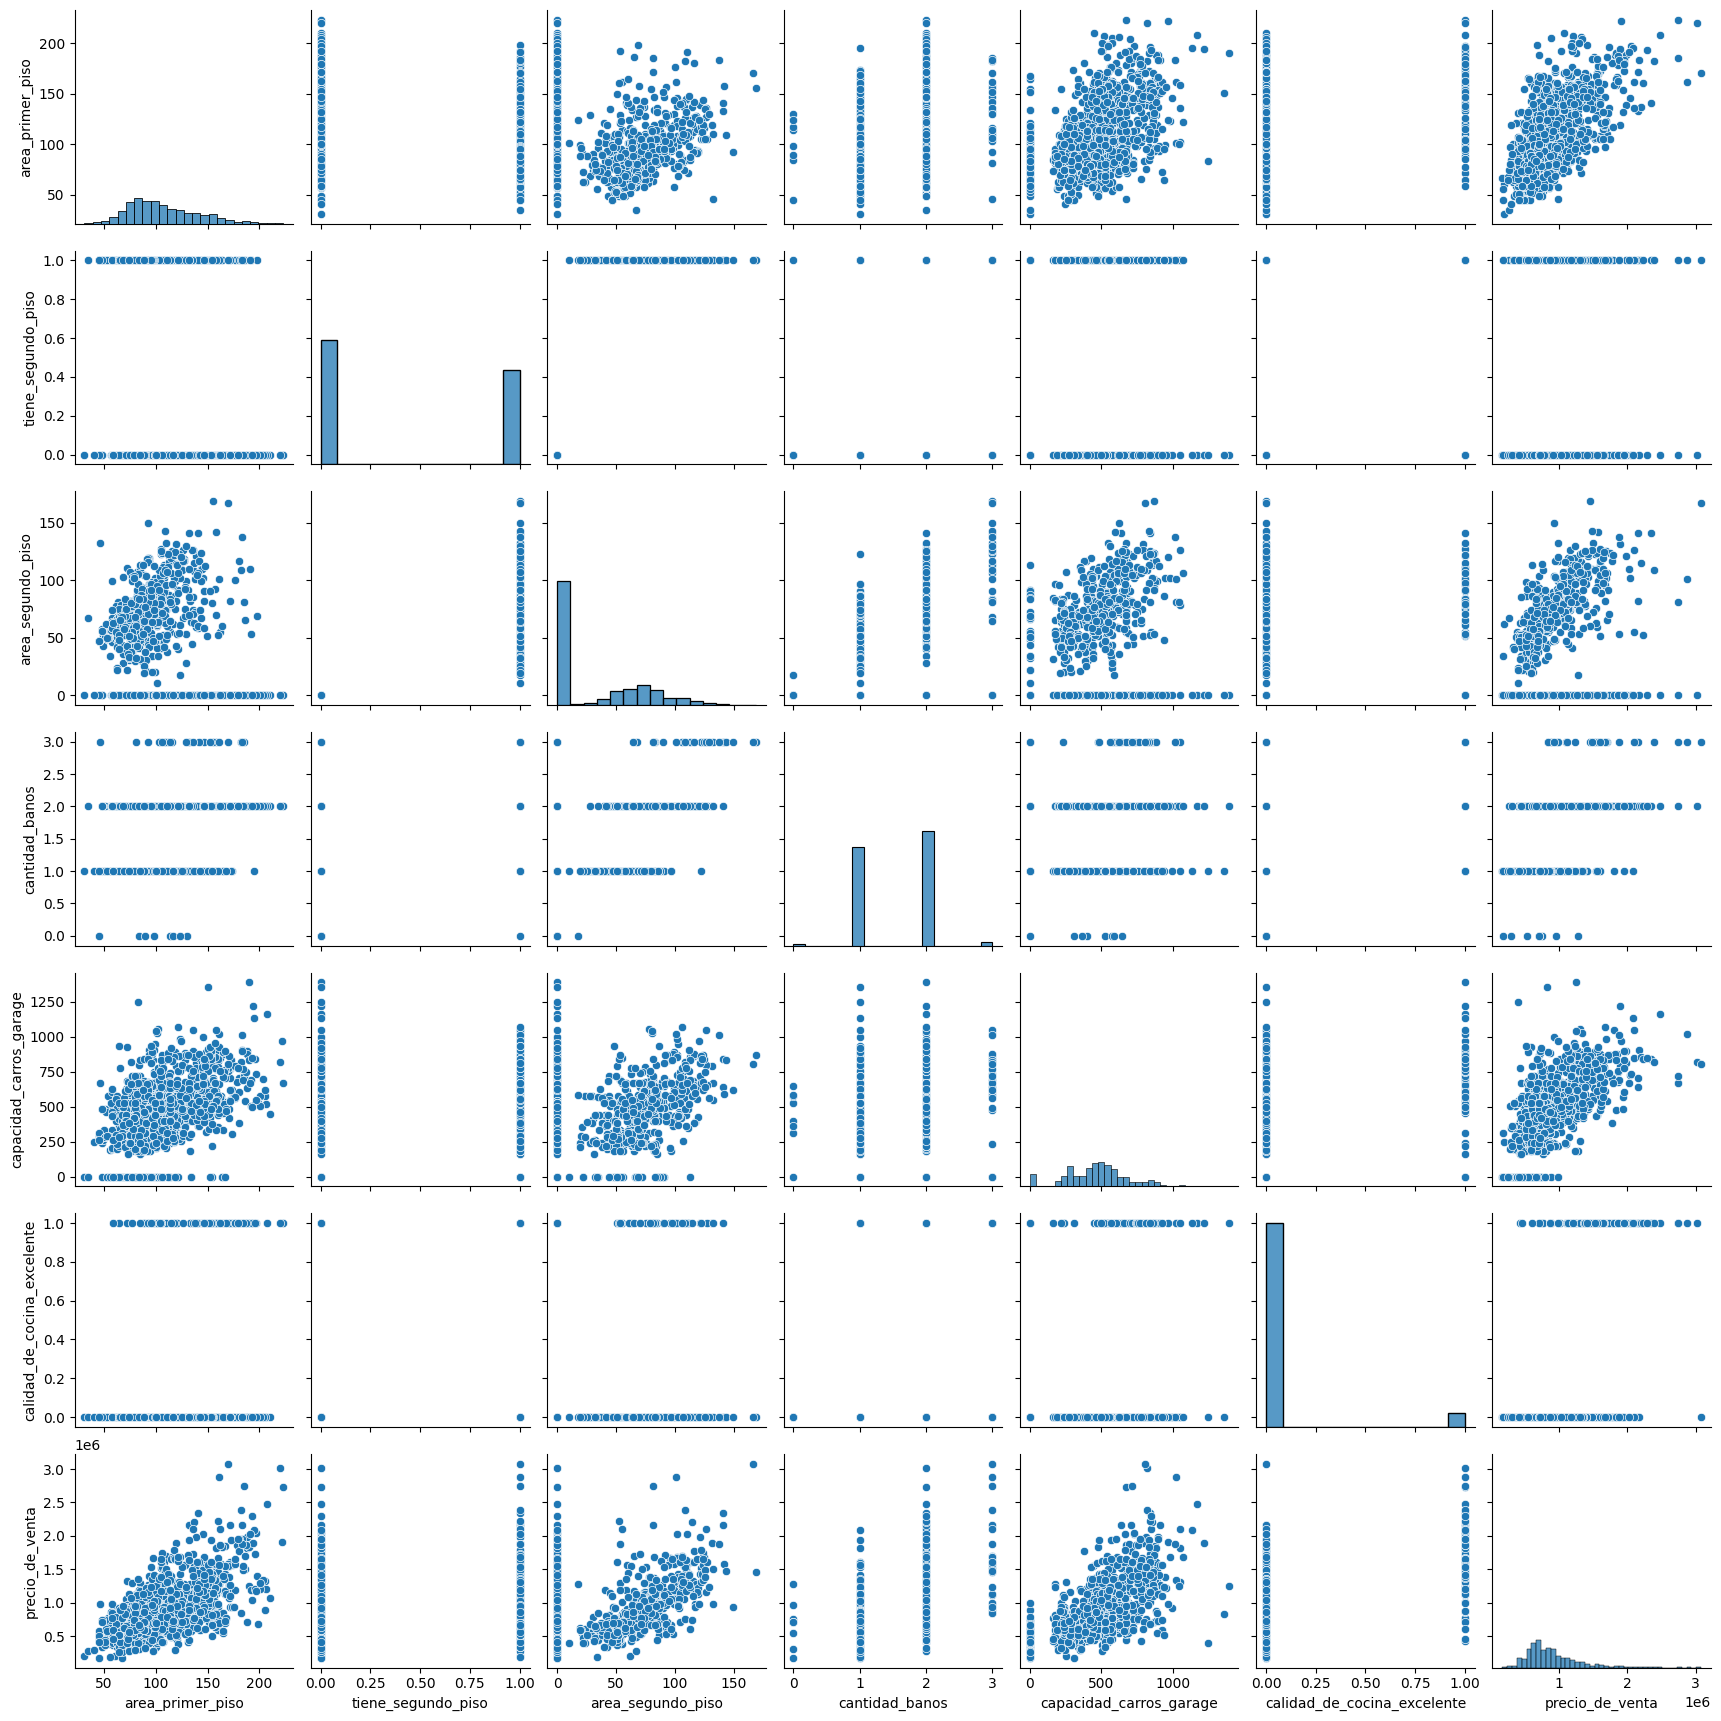

In [ ]:
# cuáles otras características podrían explicar el precio de los inmuebles?
sns.pairplot(datos)   #grafico scatter para tipo de variavble de base de datos
plt.show()



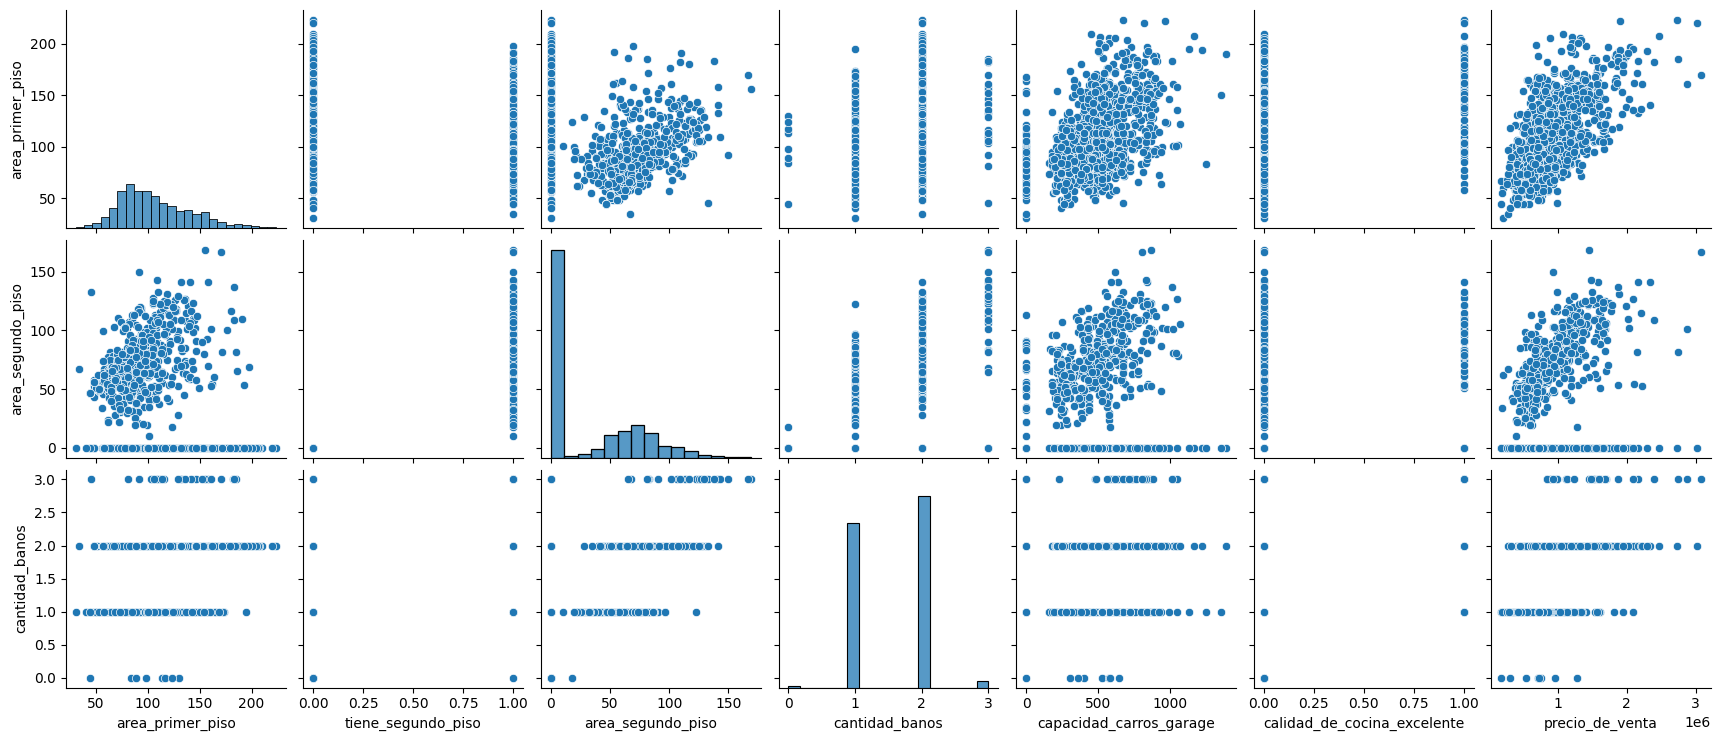

In [ ]:
#Vamos a analizar con tres variables
sns.pairplot(datos, y_vars=["area_primer_piso", "area_segundo_piso", "cantidad_banos"])
plt.show()
#y_vars : variables a analizaer en eje y

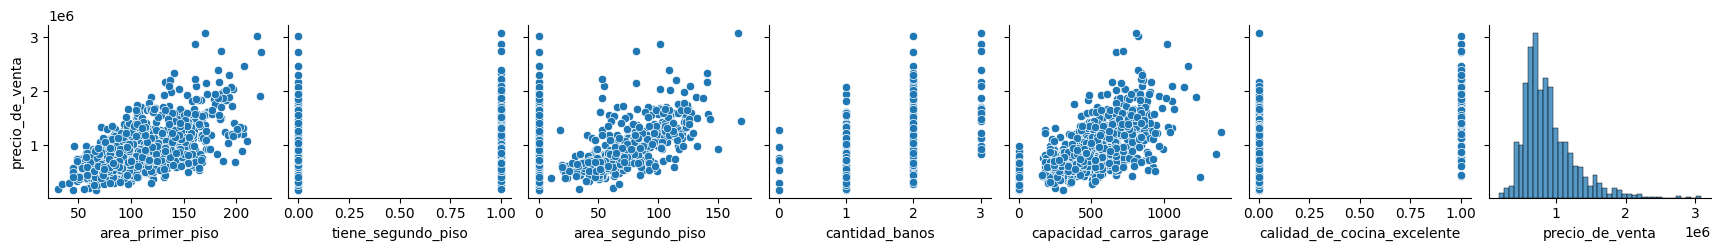

In [ ]:
#Vamos a analizar solamente y_vars='precio_de_venta'
sns.pairplot(datos, y_vars="precio_de_venta")
plt.show()

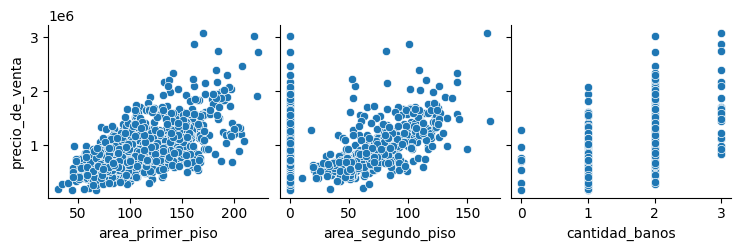

In [ ]:
#Vamos a analizar solamente y_vars='precio_de_venta' , x_vars=["area_primer_piso", "area_segundo_piso", "cantidad_banos"]
sns.pairplot(datos, y_vars="precio_de_venta", x_vars=["area_primer_piso", "area_segundo_piso", "cantidad_banos"])

plt.show()
# y_vars : variables a analizar en eje y
# x_vars : variables a analizar en eje x

## Añadiendo factores al modelo

In [ ]:
# importando la api de statsmodels
import statsmodels.api as sm


In [ ]:
X_train.head()

,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente
1303,65.7732,0,0.0000,1,0,0
326,55.3684,1,55.3684,1,189,0
386,74.6916,1,107.4853,2,560,0
615,103.6764,0,0.0000,1,440,0
236,94.2006,1,67.8170,2,457,0


**Añadir constante a nuestro conjunto entrenamiento**
- Sirve para hallar el intercepto, para obtener el valor de variable dependiente cuando todas las variables sean 0
- el metodo sm.OSL() no incluye un intercepto por eso es necesario crear uno
- el metodo sm.Osl() nos crea una recta que pasa por eje de coordenas si no creamos un intercepto


recta de regresion si no añadir la columna const, donde pasa por el eje de coordenadas (mayor de error datos)

$$y = (\text{Coeficiente}_1 \cdot \text{Variable}_1) + (\text{Coeficiente}_2 \cdot \text{Variable}_2) + \dots$$


Cuando se añade una columna const con valores de 1s

$$y = b + (\text{Coeficiente}_1 \cdot \text{Variable}_1) + (\text{Coeficiente}_2 \cdot \text{Variable}_2) + \dots$$

Retroceder hasta el origen ($x=0$)

Aquí es donde ocurre la magia de la constante. El modelo ya tiene el ancla (el promedio) y la inclinación (la pendiente). Ahora, para hallar el intercepto $b$, hace una "proyección hacia atrás" usando esta lógica:

"Si en el punto promedio ($90 m^2$) el precio es $764,300$, y yo sé que el precio baja $6,793.64$ por cada metro que quito, ¿cuánto valdría la casa si le quito los $90$ metros hasta llegar a cero?"


$$b = 764,300 - (6,793.64 \cdot 90) = 152,902$$

$$b = \bar{y} - (m \cdot \bar{x})$$

$$b = \text{Precio Promedio} - (m_1 \cdot \text{Area Prom.}) - (m_2 \cdot \text{Banos Prom.}) - \dots$$

In [ ]:
# Añadiendo una constante

X_train = sm.add_constant(X_train)   #añadio columna "const" con valor de 1.0, para crear el intercepto
X_train.head()







,const,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente
1303,1.0,65.7732,0,0.0000,1,0,0
326,1.0,55.3684,1,55.3684,1,189,0
386,1.0,74.6916,1,107.4853,2,560,0
615,1.0,103.6764,0,0.0000,1,440,0
236,1.0,94.2006,1,67.8170,2,457,0


In [ ]:
X_train.columns   #variables o columnas de nuestro conjunto entrenamiento con constante

Index(['const', 'area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente'],
      dtype='object')

In [ ]:
# Creando el modelo de regresión (con todas las variables): saturado
model_1 = sm.OLS(y_train, X_train).fit()


In [ ]:
# Modelo sin el área del segundo piso
model_2 = sm.OLS(y_train, X_train[['const', 'area_primer_piso', 'tiene_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente']]).fit()


In [ ]:
# Modelo sin la información del garage
# Modelo sin el área del segundo piso
model_3 = sm.OLS(y_train, X_train[['const', 'area_primer_piso', 'tiene_segundo_piso',
       'cantidad_banos',
       'calidad_de_cocina_excelente']]).fit()

In [ ]:
# Resumen del modelos
modelos = [model_0, model_1, model_2, model_3]

for i,j in enumerate(modelos):
  print(f"------------------------------------------------------------------------------\n--------- el modelo {i} tiene el siguiente resumen\n : ")
  print(f"{j.summary()}\n\n")


------------------------------------------------------------------------------
--------- el modelo 0 tiene el siguiente resumen
 : 
                            OLS Regression Results                            
Dep. Variable:        precio_de_venta   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          2.22e-105
Time:                        16:45:45   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      

In [ ]:
for i, j in enumerate(modelos):
  print(f"el R cuadrado para el modelo {i} es : {j.rsquared.round(2)}")

el R cuadrado para el modelo 0 es : 0.38
el R cuadrado para el modelo 1 es : 0.74
el R cuadrado para el modelo 2 es : 0.71
el R cuadrado para el modelo 3 es : 0.65


Usamos el **modelo 3** yaque es el que no tiene strong multicollinearity, que hace que haya variables que se superponen y su explicacion de la variacion de precios no sea tan clara, por eso hemos eliminado algunas variables del conjunto de entrenamiento para el modelo 3 para evitar esos problemas de cruce, ademas de tener un R cudrado considerable de 65% que explica la variacion de los precios de venta

## Comparando los modelos
Cuál es el modelo?


In [ ]:
# Cuántos parámetros tiene el modelo?
model_3.params

#por cada aumento de una unidad de una variable (indice) varia x (columna) del precio de venta

#  por cada aumento de la variable calidad_de_cocina_excelente
#  aumenta en 444391 el precio de venta con una variacion de 28,800
#  esto quiere decir que la calidad de la cocina influye en un buen cantidad en el precio de venta

,0
const,-129979.678094
area_primer_piso,6119.653184
tiene_segundo_piso,221306.959705
cantidad_banos,149036.289458
calidad_de_cocina_excelente,444391.228573


# 4. Precificando las casas

## Obteniendo el R² de la previsión

In [ ]:
# Añadiendo una constante en X_test
X_test= sm.add_constant(X_test)


In [ ]:
X_test.head(2)

,const,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente
997,1.0,94.9438,0,0.0000,1,280,0
805,1.0,74.1342,1,78.2218,2,595,0


In [ ]:
# Previsión con el modelo 3, prediccion

y_predict_3 = model_3.predict(X_test[['const', 'area_primer_piso', 'tiene_segundo_piso',
       'cantidad_banos',
       'calidad_de_cocina_excelente']])
# para usar la formula hallada, necesetia un constant para utilizar el intercepto
# solo vamos a usar las variables que se usaran en el entrenamiento dle model_3


- $R^2$ Entrenamiento > $R^2$ Prueba (mucha diferencia): Sobreajuste (Overfitting).
- $R^2$ Entrenamiento $\approx$ $R^2$ Prueba: Modelo robusto y confiable (como el tuyo de 0.65 y 0.64).
- $R^2$ muy bajo en ambos: Subajuste (Underfitting); el modelo es demasiado simple para el problema.

In [ ]:
# Cuál es el r² de la previsión?
round(r2_score(y_test, y_predict_3), 2)


0.64

In [ ]:
# Cuál es el R² del entrenamiento?
round(model_3.rsquared, 2)

# vemos que el r cuadrado de la prevision con el entrenamiento esta muy cercanos,
# lo cual nos indica que es solido nuestro modelo, explicando el 65% de las variaciones del precio}

# El modelo explica el 65% de la varianza de la variable dependiente (precio de venta)
# tanto en los datos de entrenamiento como en los de prueba, lo que valida su estabilidad

np.float64(0.65)

## Precificando una casa

<img src="https://i.ibb.co/SvG4V4j/costo.png" alt="costo" border="0">

In [ ]:
datos.columns

Index(['area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente', 'precio_de_venta'],
      dtype='object')

In [ ]:
round(model_0.rsquared,2)


np.float64(0.38)

In [ ]:
#Nuevo inmueble
nuevo_inmueble = pd.DataFrame({
    "const" : [1],
    "area_primer_piso" : [120],
    "tiene_segundo_piso" : [1],
    "cantidad_banos" : [2],
    "calidad_de_cocina" : [0]
})

In [ ]:
# Cuál es el precio del inmueble de acuerdo con el modelo 0?

round(model_0.predict(nuevo_inmueble), 2)
#model_0 que tiene un 38% de explicatiblidad de la variacion del precio


,0
0,968146.29


In [ ]:
#Cuál es el precio del inmueble de acuerdo con el modelo 3?

round(model_3.predict(nuevo_inmueble), 2)
#model_3 que tiene un 65% de explicatiblidad de la variacion del precio


,0
0,1123758.24


In [ ]:
model_3.params
#por cada unidad (indices) mas de cada variable varia en en el preci de cada variable (columna)

,0
const,-129979.678094
area_primer_piso,6119.653184
tiene_segundo_piso,221306.959705
cantidad_banos,149036.289458
calidad_de_cocina_excelente,444391.228573


## Precificando varias casas

<img src="https://i.imgur.com/i0skFlB.jpeg" width="600"/>

In [ ]:
# Leyendo varias casas?
nuevas_casas = pd.read_csv("nuevas_casas.csv", sep=";")
nuevas_casas.head(2)



,Casa,area_primer_piso,tiene_segundo_piso,cantidad_banos,calidad_de_cocina_excelente
0,1,150,1,2,1
1,2,180,0,3,1


In [ ]:
nuevas_casas = nuevas_casas.drop(columns="Casa")
#eliminamos columna Casa, ya que es lo mismo que el indice, irrelevante

In [ ]:
# Añadiendo una constante

nuevas_casas = sm.add_constant(nuevas_casas)
# añadimos columna const con valores de 1s, para crear el intercepto de la recta regresion
# solo se usa cuando usamos sm.ols

In [ ]:
nuevas_casas.head(2)

,const,area_primer_piso,tiene_segundo_piso,cantidad_banos,calidad_de_cocina_excelente
0,1.0,150,1,2,1
1,1.0,180,0,3,1


In [ ]:
# Cuál es el precio de estas nuevas casas?

nuevas_casas["precio_de_venta"] = round(model_3.predict(nuevas_casas), 2)
# creamos una columna donde se guardaran los precios predecidos con
# los datos de nuevas casas (conjunto de prueba)
# round() : formato de los precios sera con 2 decimales


In [ ]:
nuevas_casas.head()

,const,area_primer_piso,tiene_segundo_piso,cantidad_banos,calidad_de_cocina_excelente,precio_de_venta
0,1.0,150,1,2,1,1751739.07
1,1.0,180,0,3,1,1863057.99
2,1.0,120,1,2,1,1568149.47
3,1.0,200,1,3,1,2206758.02
4,1.0,160,0,2,1,1591628.64


Recibiste una solicitud para estimar el precio de una casa con las siguientes características:

- 1 baño
- Área 98m²
- No tiene segundo piso
- Calidad de la cocina excelente

Tu tarea es utilizar el modelo de regresión entrenado durante el curso para obtener el precio de la casa con estas características. Por lo tanto, crea un DataFrame con esta información y haz la predicción del valor del inmueble.

- usando el model_3



In [ ]:
datos.columns

Index(['area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente', 'precio_de_venta'],
      dtype='object')

In [ ]:
nuevo_inmueble = pd.DataFrame({
    "const" : [1],
    "area_primer_piso" : [98],
    "tiene_segundo_piso" : [0],
    "cantidad_banos" : [1],
    "calidad_de_cocina_excelente" : [1]
})

nuevo_inmueble

,const,area_primer_piso,tiene_segundo_piso,cantidad_banos,calidad_de_cocina_excelente
0,1,98,0,1,1


Hallar el precio tomando en cuenta todas las variables descritas, la cual tiene el model_3

In [ ]:
nuevo_inmueble["precio_de_venta"] = round(model_3.predict(nuevo_inmueble),2)
nuevo_inmueble

,const,area_primer_piso,tiene_segundo_piso,cantidad_banos,calidad_de_cocina_excelente,precio_de_venta
0,1,98,0,1,1,1063173.85


Hallar el precio tomando en cuenta solo la variable area_primer_piso, la cual tiene el model_0

In [ ]:
round(model_0.predict(nuevo_inmueble), 2)[0]

# la funcion predict() solo usa las variables con las que se entreneo el modelo
# osea obvia variables del conjunto prueba que no fueron entrenadas con el modelo
#   pero solo cuando el modelo es entrenado con ols() y no con sm.ols(), este ultimo se tiene que especificar

np.float64(818686.17)

## Guardando el modelo con **pickle**

In [ ]:
import pickle

In [ ]:
nombre_modelo = "regresion_lineal_precios_model_3.pkl"

with open(nombre_modelo, "wb") as archivo:   #guardamos el model_3 en un archivo con un nombre
  pickle.dump(model_3, archivo)

Importando el modelo con pickle

In [ ]:
with open(nombre_modelo, "rb") as archivo:    #cargamos el archivo donde esta el modelo
  model_3_importado = pickle.load(archivo)

In [ ]:
model_3_importado   #tenemos el modelo importado, listo para usar

In [ ]:
model_3_importado.params    #como vemos tiene todos sus varaibles con las que se entreno

,0
const,-129979.678094
area_primer_piso,6119.653184
tiene_segundo_piso,221306.959705
cantidad_banos,149036.289458
calidad_de_cocina_excelente,444391.228573


In [ ]:
model_3.params

,0
const,-129979.678094
area_primer_piso,6119.653184
tiene_segundo_piso,221306.959705
cantidad_banos,149036.289458
calidad_de_cocina_excelente,444391.228573


In [ ]:
model_3_importado.rsquared   #tiene le el mismo r cuadrado

np.float64(0.6511289354898803)

In [ ]:
model_3.rsquared

np.float64(0.6511289354898803)

# 5. Investigando el modelo





## Multicolinearidad

Cuando dos o más cosas que estás intentando estudiar son tan parecidas que es difícil determinar cuánto está influyendo cada una de ellas en el resultado.
- lo ideal es que las variables puedan explicar la variacion de la varaible dependiente por separado, pero si hay variables que son muy parecidad, estas explicacones se superponen y no hay claridad cuanto puede explicar cada una dando el resultado final una prediccion no tan acertada, a pesar que su $R^2$ indique lo contrario

In [ ]:
# importar el VIF de statsmodel

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
# factor de inflacion de la varianza (VIF)

In [ ]:
X_train.columns

Index(['const', 'area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente'],
      dtype='object')

variables explicativas del model_1

In [ ]:
model_1.params   #todas las variables explicativas

,0
const,-61251.345023
area_primer_piso,4875.960595
tiene_segundo_piso,-134400.681632
area_segundo_piso,4709.382433
cantidad_banos,64629.613915
capacidad_carros_garage,432.761421
calidad_de_cocina_excelente,377918.770713


In [ ]:
explicativas_1 = ['const', 'area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente']

variables explicativas del model_2

In [ ]:
model_2.params  #todas las variables explicativas

,0
const,-141763.879013
area_primer_piso,4746.113406
tiene_segundo_piso,192920.027424
cantidad_banos,106978.502270
capacidad_carros_garage,507.406766
calidad_de_cocina_excelente,384861.525470


In [ ]:
explicativas_2 = ['const', 'area_primer_piso', 'tiene_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente']

variables explicativas el model_3

In [ ]:
model_3.params    #todas las variables explicativas

,0
const,-129979.678094
area_primer_piso,6119.653184
tiene_segundo_piso,221306.959705
cantidad_banos,149036.289458
calidad_de_cocina_excelente,444391.228573


In [ ]:
explicativas_3 = ['const', 'area_primer_piso', 'tiene_segundo_piso',
       'cantidad_banos',
       'calidad_de_cocina_excelente']

In [ ]:
X_train.head(1)   #conjunto de entrenamiento

,const,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente
1303,1.0,65.7732,0,0.0,1,0,0


Nos permite entender si existe Multicolineraridad entre variables
- si hay variables > 5 --> hay Multicolinearidad fuerte, por lo tanto no es recomendable usar un modelo con esta caracteristica

In [ ]:
vif(X_train[explicativas_1], 2)
#factor de variacion de inflacion de variable posicion 2 (columns )e DataFrame X_train

np.float64(7.455059406230703)

In [ ]:
# VIF 1   -  model_1

VIF_1 = pd.DataFrame()                  #crea DataFrame
VIF_1["variables"] = explicativas_1     #crea columna "variables" con nombre de las variables
VIF_1["VIF"] = [vif(X_train[explicativas_1],i) for i in range(len(explicativas_1))]
# guardar los valores vif en cada fila correspondiante a su variable en columna creada "VIF"
VIF_1

# vemos que hay 2 variables que son > 5 --> hay Multicolinearidad fuerte
# conclusion : la variable "tiene_segundo_piso" y "area_segundo_piso" son muy similares
# que chocan ante la explicacion de la variacion del precio


,variables,VIF
0,const,20.230833
1,area_primer_piso,2.193680
2,tiene_segundo_piso,7.455059
3,area_segundo_piso,7.589396
4,cantidad_banos,1.720795
5,capacidad_carros_garage,1.570078
6,calidad_de_cocina_excelente,1.182606


In [ ]:
# VIF 3

VIF_3 = pd.DataFrame()                  #crea DataFrame
VIF_3["variables"] = explicativas_3     #crea columna "variables" con nombre de las variables
VIF_3["VIF"] = [vif(X_train[explicativas_3],i) for i in range(len(explicativas_3))]
# guardar los valores vif en cada fila correspondiante a su variable en columna creada "VIF"
VIF_3


# todas las variables son < 5 ---> no hay Multicolinearidad
# conclusion : es un factor que podemos considerar para elegir un modelo

,variables,VIF
0,const,18.773457
1,area_primer_piso,1.919046
2,tiene_segundo_piso,1.644067
3,cantidad_banos,1.539255
4,calidad_de_cocina_excelente,1.151795


## Análisis de los residuos

Residuos: la discrepancia entre los valores reales y los valores que el modelo predice para los mismos puntos de datos.

Vamos a traer los valores ajustados que hallo el modelo con el conjunto entrenamiento para luego comparar con los precios reales (y_train) y que que hasta donde el modelo predice el resultado bien

In [ ]:
y_previsto_train_3 = model_3.predict(X_train[explicativas_3])
#obtenemos los valores ajustados (recta) en el entramiento

In [ ]:
y_previsto_train_3.head()   #valores ajustados (primera recta regresion calculado con el conjutno entrenamiento)

,0
1303,421565.784163
326,579198.976419
386,846486.548282
615,653520.222725
236,965874.862248


In [ ]:
y_train.head()     #valores reales para el conjunto entrenamiento

,precio_de_venta
1303,406725.0
326,384540.0
386,1059950.0
615,788800.0
236,958885.0


In [ ]:
fig = px.scatter(x = y_previsto_train_3, y = y_train,
                 title="valor Provisto vs Real (conjunto Entrenamiento)",
                 labels={'x': 'Valor Previsto', 'y':"Valor Real"})
# grafica scatter para ver la relacion de precios previsto y precios reales


fig.add_shape(
    type="line",
    x0=y_previsto_train_3.min(), y0=y_previsto_train_3.min(), # Punto inicial (mismo valor en x e y)
    x1=y_previsto_train_3.max(), y1=y_previsto_train_3.max(), # Punto final (mismo valor en x e y)
    line=dict(color="Red", width=2, dash="dash"),
)
# recta simetrica que representa la perfeccion, 100% prediccion
# recta que representa si los valores previstos son iguales al real
# mientras mas alejado a la recta significa que la prediccion baja
# mientras mas cerca a la recta la prediccion es mayor en esa area

#los puntos por encima recta : precio real > precio previsto
#los puntos debajo recta : precio real < precio previsto
#los puntos que coninciden con la recta : precio real = precio previsto

# rango de 500000 a 1000000 los precios son mas precisos, mayor prediccion
# rango superior a 1000000 no es muy preciso, casas mas caras es menos preciso el modelo

fig.show()

In [ ]:
residuos_train = model_3.resid  #guardamos todos los residuos

fig = px.scatter(x = y_previsto_train_3, y = residuos_train,
                 title="valor Provisto vs Residuos (Conjunto entrenamiento)",
                 labels={'x': 'Valor provisto', 'y':"Residuo (real - prediccion)"})
# grafica scatter para ver la relacion de precios previsto y precios reales


fig.add_shape(
    type="line",
    x0=0, y0=0, # Punto inicial (mismo valor en x e y)
    x1=y_provisto_3.max(), y1=0, # Punto final (mismo valor en x e y)
    line=dict(color="Red", width=2, dash="dash"),
)
# recta simetrica que representa la perfeccion, 100% prediccion
# recta que indica que si los puntos estan mas cerca a 0 hay mayor prediccion

# mientras mas alejado a la recta significa que la prediccion baja
# mientras mas cerca a la recta la prediccion es mayor en esa area

#los puntos por encima recta : precio real > precio previsto
#los puntos debajo recta : precio real < precio previsto
#los puntos que coninciden con la recta : precio real = precio previsto

# rango de 500000 a 1000000 los precios son mas precisos, mayor prediccion
# rango superior a 1000000 no es muy preciso, casas mas caras es menos preciso el modelo

fig.show()

## Analizando el comportamiento del modelo con conjunto de prueba, para ver que tanto explica con conjunto nuevo

In [ ]:
y_previsto_test_3 = model_3.predict(X_test[explicativas_3])
#obtenemos los valores predecidos (rcta regresion) con un conjunto prueba


In [ ]:
fig = px.scatter(x = y_previsto_test_3, y = y_test,
                 title="valor Provisto vs Real (Conjunto prueba)",
                 labels={'x': 'Valor Previsto', 'y':"Valor Real"})
# grafica scatter para ver la relacion de precios previsto y precios reales del conjunto prueba


fig.add_shape(
    type="line",
    x0=y_previsto_test_3.min(), y0=y_previsto_test_3.min(), # Punto inicial (mismo valor en x e y)
    x1=y_previsto_test_3.max(), y1=y_previsto_test_3.max(), # Punto final (mismo valor en x e y)
    line=dict(color="Red", width=2, dash="dash"),
)
# recta simetrica que representa la perfeccion, 100% prediccion
# recta que representa si los valores previstos son iguales al real
# mientras mas alejado a la recta significa que la prediccion baja
# mientras mas cerca a la recta la prediccion es mayor en esa area

#los puntos por encima recta : precio real > precio previsto
#los puntos debajo recta : precio real < precio previsto
#los puntos que coninciden con la recta : precio real = precio previsto

# rango de 500000 a 1000000 los precios son mas precisos, mayor prediccion
# rango superior a 1000000 no es muy preciso, casas mas caras es menos preciso el modelo

fig.show()

Analizemos los residuos para ver el comportamiento de los residuos y ver si tiene heterocedasticidad o homocedasticidad
- heterocedasticidad : los residuos del modelo no tienden a ser constantes, sino que incremente o disminyen, o toman otro compoartmiento, por lo tanto el modelo debe ser tratado para manejar mejor la prediccion en valores mas altos
- homocedasticidad : los residuos tienden un rango constante, lo cual indica que el modelo es solido y su prediccion es mas precisa en todo ese rango

In [ ]:
residuos_test = model_3.resid  #guardamos todos los residuos

fig = px.scatter(x = y_previsto_train_3, y = residuos_test,
                 title="valor Provisto vs Residuos (Conjunto entrenamiento)",
                 labels={'x': 'Valor provisto', 'y':"Residuo (real - prediccion)"})
# grafica scatter para ver la relacion de precios previsto y precios reales


fig.add_shape(
    type="line",
    x0=0, y0=0, # Punto inicial (mismo valor en x e y)
    x1=y_provisto_3.max(), y1=0, # Punto final (mismo valor en x e y)
    line=dict(color="Red", width=2, dash="dash"),
)
# recta simetrica que representa la perfeccion, 100% prediccion
# recta que indica que si los puntos estan mas cerca a 0 hay mayor prediccion

# mientras mas alejado a la recta significa que la prediccion baja
# mientras mas cerca a la recta la prediccion es mayor en esa area

#los puntos por encima recta : precio real > precio previsto
#los puntos debajo recta : precio real < precio previsto
#los puntos que coninciden con la recta : precio real = precio previsto

# rango de 500000 a 1000000 los precios son mas precisos, mayor prediccion
# rango superior a 1000000 no es muy preciso, casas mas caras es menos preciso el modelo

fig.show()

Vemos que nuestro modelo tiene heterocedasticidad

<img src="https://i.ibb.co/9bmySbm/heterocedasticidad.png" alt="heterocedasticidad" border="0">

Actividad aula 3

In [ ]:
datos_1 = pd.read_csv("hoteis.csv")
datos_1.head()

,Estrelas,ProximidadeTurismo,Capacidade,Preco
0,5,9.301565,3,506.275452
1,1,1.785891,1,246.363458
2,4,15.504293,3,325.873550
3,4,4.173188,3,521.343284
4,4,9.443685,1,252.587087


En esta actividad, tu tarea consiste en llevar a cabo las siguientes etapas:

- análisis inicial con el PairPlot de Seaborn;
- construir modelos de regresión lineal; y
- realizar la comparación de estos modelos.

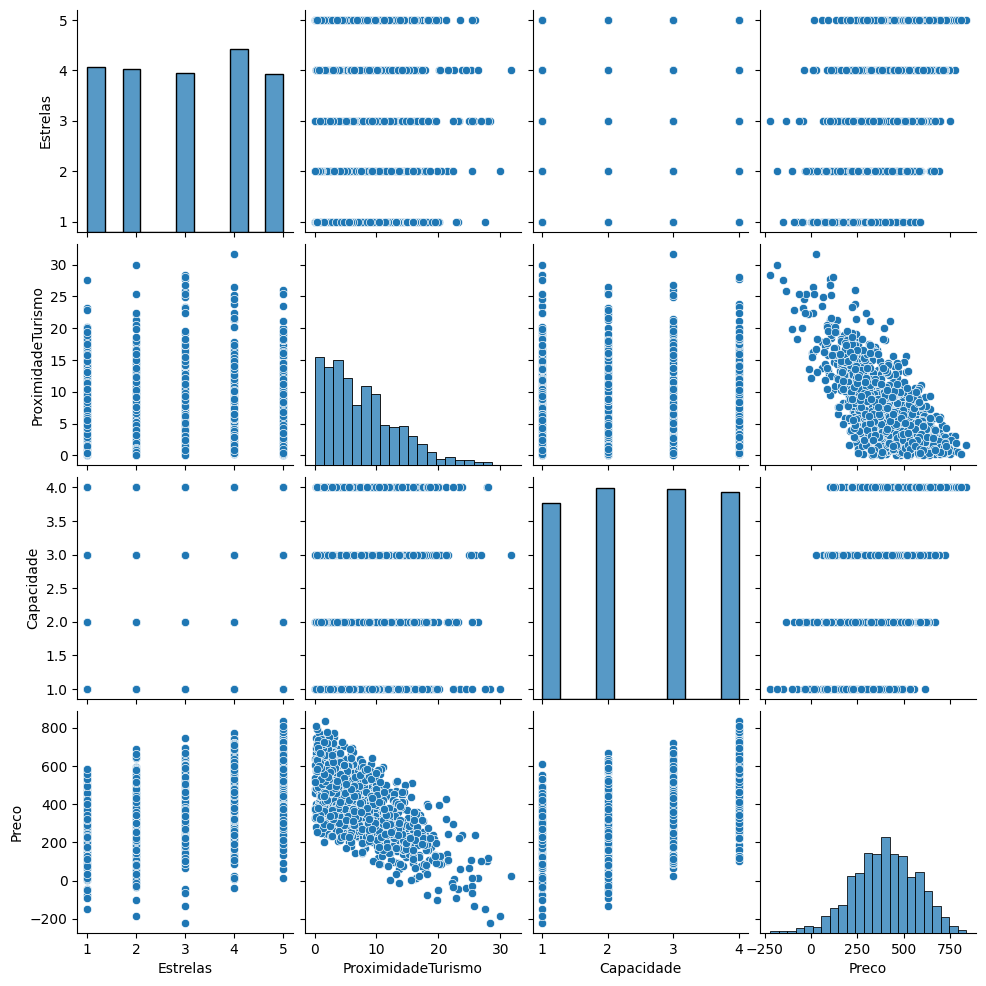

In [ ]:
sns.pairplot(datos_1)

In [ ]:
corr_1 = datos_1.corr()

In [ ]:
corr_1

,Estrelas,ProximidadeTurismo,Capacidade,Preco
Estrelas,1.000000,0.005237,-0.023200,0.401099
ProximidadeTurismo,0.005237,1.000000,-0.027050,-0.697142
Capacidade,-0.023200,-0.027050,1.000000,0.531866
Preco,0.401099,-0.697142,0.531866,1.000000


In [ ]:
y_1 = datos_1["Preco"]
X_1 = datos_1.drop(columns="Preco")

In [ ]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.3, random_state=230)

In [ ]:
df_train_1 = pd.DataFrame(X_1)
df_train_1["Preco"] = y_1

In [ ]:
X_train_1 = sm.add_constant(X_train_1)

In [ ]:
X_train_1.columns

Index(['const', 'Estrelas', 'ProximidadeTurismo', 'Capacidade'], dtype='object')

In [ ]:
modelo_0 = sm.OLS(y_train_1, X_train_1).fit()  #modelo usando todas las variables independientes


In [ ]:
modelo_1 = sm.OLS(y_train_1, X_train_1[['const', 'Estrelas', 'ProximidadeTurismo']]).fit()


In [ ]:
modelo_2 = sm.OLS(y_train_1, X_train_1[['const', 'Estrelas']]).fit()


In [ ]:
modelos_1 = [modelo_0, modelo_1, modelo_2]

In [ ]:
for i, j in enumerate(modelos_1):
  print(f"------------------------------------------------------------------------------\n--------- el modelo {i} tiene el siguiente resumen\n : ")
  print(f"{j.summary()}\n\n")

------------------------------------------------------------------------------
--------- el modelo 0 tiene el siguiente resumen
 : 
                            OLS Regression Results                            
Dep. Variable:                  Preco   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     2828.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:45:48   Log-Likelihood:                -3689.2
No. Observations:                 700   AIC:                             7386.
Df Residuals:                     696   BIC:                             7405.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025    

In [ ]:
for i, j in enumerate(modelos_1):
  print(f"el valor de r cuadrado del modelo {i} es : {j.rsquared.round(2)}")

el valor de r cuadrado del modelo 0 es : 0.92
el valor de r cuadrado del modelo 1 es : 0.64
el valor de r cuadrado del modelo 2 es : 0.15


Me quedo con el modelo_0 yaque tiene un porcentaje alto de explicaicon del variacion de la variable independiente

In [ ]:
modelo_0.params

,0
const,195.157575
Estrelas,50.503055
ProximidadeTurismo,-20.356643
Capacidade,81.526144


Actividad aula 5

En esta actividad, vamos a aplicar los conceptos de multicolinealidad y homocedasticidad en un contexto diferente: el sector de energía. Utilizaremos este dataset de una planta de energía para explorar cómo estos conceptos pueden afectar nuestros modelos de regresión. ¡Vamos!

Tu tarea implica llevar a cabo las siguientes etapas:

**Primera etapa**: Verifica la multicolinealidad utilizando el concepto de VIF. Si hay indicios de multicolinealidad entre las variables, intenta pensar en qué medidas se pueden tomar. Para ello, deberás construir un modelo de regresión lineal asumiendo que la columna PE es la variable y.

**Segunda etapa**: Realiza un análisis de residuos e identifica si hay o no heterocedasticidad en los datos.

In [ ]:
datos_energia = pd.read_csv("usina.csv")
datos_energia.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [ ]:
y_2 = datos_energia["PE"]                   #variable respuesta/dependiente
X_2 = datos_energia.drop(columns=["PE"])    #variables independientes

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.3, random_state=230)
#repartir los datos de cada variable en 2 pares de conjuntos para entrenamiento y prueba

In [ ]:
X_train_2 = sm.add_constant(X_train_2)

In [ ]:
X_2.columns

Index(['const', 'AT', 'V', 'AP', 'RH'], dtype='object')

In [ ]:
explicacion_1 = ['const', 'AT', 'V', 'AP', 'RH']

In [ ]:
vif_1 = pd.DataFrame()
vif_1["variables"] =  explicacion_1
vif_1['VIF'] = [vif(X_train_2, i) for i in range(len(explicacion_1))]

vif_1

# hay multicolinealidad mediana VIF > 5, no contrar el const,
# por lo tanto no es recomendable, ya que la precision se vera afectada

,variables,VIF
0,const,44603.788615
1,AT,6.034363
2,V,3.954998
3,AP,1.468530
4,RH,1.717508


In [ ]:
explicacion_2 = ['const', 'V', 'AP', 'RH']

vif_2 = pd.DataFrame()
vif_2["variables"] =  explicacion_2
vif_2['VIF'] = [vif(X_train_2[['const', 'V', 'AP', 'RH']], i) for i in range(len(explicacion_2))]

vif_2

#variables con las que hay menos multicolinealidad y obteniendo mas variables, VIF < 5

,variables,VIF
0,const,36577.789437
1,V,1.327768
2,AP,1.215769
3,RH,1.104508


In [ ]:
explicacion_3 = ['const', 'AT', 'AP', 'RH']

vif_3 = pd.DataFrame()
vif_3["variables"] =  explicacion_3
vif_3['VIF'] = [vif(X_train_2[explicacion_3], i) for i in range(len(explicacion_3))]

vif_3

# multicolinealidad baja, VIF < 5, es el segundo con menor VIF

,variables,VIF
0,const,44014.355564
1,AT,2.025850
2,AP,1.446885
3,RH,1.505641


In [ ]:
modelo_1 = sm.OLS(y_train_2, X_train_2[explicacion_1]).fit()
modelo_2 = sm.OLS(y_train_2, X_train_2[explicacion_2]).fit()
modelo_3 = sm.OLS(y_train_2, X_train_2[explicacion_3]).fit()

In [ ]:
for i, j in enumerate([modelo_1, modelo_2, modelo_3]):
  print(f"------------------------------------------------------------------------------\n--------- el modelo {i+1} tiene el siguiente resumen\n : ")
  print(f"{j.summary()}\n\n")

------------------------------------------------------------------------------
--------- el modelo 1 tiene el siguiente resumen
 : 
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.191e+04
Date:                Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:27:53   Log-Likelihood:                -19662.
No. Observations:                6697   AIC:                         3.933e+04
Df Residuals:                    6692   BIC:                         3.937e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]

In [ ]:
for i, j in enumerate([modelo_1, modelo_2, modelo_3]):
  print(f"el r cuadrado del medolo {i+1} es : {round(j.rsquared, 2)}")

el r cuadrado del medolo 1 es : 0.93
el r cuadrado del medolo 2 es : 0.81
el r cuadrado del medolo 3 es : 0.92


Conclusiones de los modelos:
- modelo_1 : tiene una variable con VIF > 5, lo que nos indica que tiene caracteristicas parecidas a otras, descartada
- modelo_2 : mas variables mas cerca a 1, tiene VIF < 5, sus variables explican con claridad, su $R^2$ = 80%
- modelo_3 : segundo con mas variables cerca a 1, tiene VIF < 5, sus variables explican con claridad, su $R^2$ = 92%

Conclusion : el **modelo_3** tiene mayor porcentaje de explicacion de variacion de los precios, apesar de tener las variables menos cerca a 1 en el VIF que el modelo_2, yaque aqui se prioriza que modelo tiene mayor es mas preciso
- primer criterio : VIF < 5?
- segundo criterio : quien tiene mayor $R^2$ y $R^2$ ajustado no varie tanto de de $R^2$

Se elige al modelo_3

**Segunda etapa**: Realiza un análisis de residuos e identifica si hay o no heterocedasticidad en los datos.

In [ ]:
y_previsto_2 = modelo_3.predict(X_train_2[explicacion_3])  #obtenemos los valores predecidos en el entrenamiento

In [ ]:
residuos_train_2 = modelo_3.resid   #guardamos los residuos obtenidos en el entramiento (real - predecido)

In [ ]:
fig_2 = px.scatter(x = y_previsto_2, y= y_train_2,
                   title="Previsto vs Real (Conjunto entrenamiento)",
                   labels={"x": "Previsto", "y": "Valor Real"},
                  symbol_sequence=['x'])

fig_2.add_shape(
    type="line",
    x0=y_train_2.min(), y0=y_train_2.min(), # Punto inicial (mismo valor en x e y)
    x1=y_train_2.max(), y1=y_train_2.max(), # Punto final (mismo valor en x e y)
    line=dict(color="Red", width=2, dash="dash"),
)

fig_2.show()

In [ ]:
fig_2 = px.scatter(x = y_previsto_2, y= residuos_train_2,
                   title="Previsto vs Real (Conjunto entrenamiento)",
                   labels={"x":"Previsto", "y": "Residuo (real - previsto)"},
                   symbol_sequence=['x'])

fig_2.add_shape(
    type="line",
    x0=y_previsto_2.min(), y0=0, # Punto inicial (mismo valor en x e y)
    x1=y_previsto_2.max(), y1=0, # Punto final (mismo valor en x e y)
    line=dict(color="Red", width=2, dash="dash"),
)

fig_2.show()

Conclusion de la grafica de residuos dle modelo_3
- heterocedasticidad leve
- Al analizar el gráfico de residuos, se observa una distribución mayoritariamente aleatoria y uniforme alrededor del eje cero. Aunque existen algunos valores atípicos en el segmento de precios más altos, no se aprecia una forma de embudo clara que indique una violación sistemática del supuesto de homocedasticidad. Por lo tanto, el modelo se considera robusto para la predicción en todo el rango evaluado.